<a href="https://colab.research.google.com/github/rauf-mifteev/Ahuntsic_AI_Optimization/blob/main/AI_TP_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intelligence Artificielle 1 — Travail Pratique 2

Optimisation : Programmation Linéaire, Glouton et Programmation Dynamique

## Partie 1 — Programmation linéaire avec PuLP

Cette première section utilise la bibliothèque PuLP pour formuler le problème mathématiquement et garantir la sélection optimale exacte des équipes.

### 1.1 Données du problème

In [2]:
joueurs = [
    {"nom": "Alice", "score": 88, "salaire": 1200, "poids": 72},
    {"nom": "Bob", "score": 91, "salaire": 1800, "poids": 85},
    {"nom": "Clara", "score": 84, "salaire": 950, "poids": 68},
    {"nom": "David", "score": 93, "salaire": 2100, "poids": 90},
    {"nom": "Emma", "score": 79, "salaire": 800, "poids": 65},
    {"nom": "Frank", "score": 87, "salaire": 2400, "poids": 95},
    {"nom": "Grace", "score": 85, "salaire": 1050, "poids": 70},
    {"nom": "Hugo", "score": 89, "salaire": 1600, "poids": 80}
]

### 1.2 Définition du problème de maximisation

In [3]:
import pulp

prob = pulp.LpProblem("Ligue_Basketball", pulp.LpMaximize)

### 1.3 Variables de décision binaires (0 ou 1)

In [4]:
# x_A[nom] = 1 si le joueur est dans l'équipe A
x_A = pulp.LpVariable.dicts("EqA", [j["nom"] for j in joueurs], cat='Binary')
x_B = pulp.LpVariable.dicts("EqB", [j["nom"] for j in joueurs], cat='Binary')

### 1.4 Fonction objective : Maximiser le score total

In [5]:
prob += pulp.lpSum([j["score"] * (x_A[j["nom"]] + x_B[j["nom"]]) for j in joueurs]), "Score_Total"

### 1.5 Contraintes

In [6]:
# Exactement 3 joueurs par équipe
prob += pulp.lpSum([x_A[j["nom"]] for j in joueurs]) == 3, "Taille_EqA"
prob += pulp.lpSum([x_B[j["nom"]] for j in joueurs]) == 3, "Taille_EqB"

# Un joueur ne peut être que dans une seule équipe (ou aucune)
for j in joueurs:
    prob += x_A[j["nom"]] + x_B[j["nom"]] <= 1, f"Unicite_{j['nom']}"

# Budget total max de 8500$
prob += pulp.lpSum([j["salaire"] * (x_A[j["nom"]] + x_B[j["nom"]]) for j in joueurs]) <= 8500, "Budget_Total"

# Poids max de 250 Kg par équipe
prob += pulp.lpSum([j["poids"] * x_A[j["nom"]] for j in joueurs]) <= 250, "Poids_EqA"
prob += pulp.lpSum([j["poids"] * x_B[j["nom"]] for j in joueurs]) <= 250, "Poids_EqB"

### 1.6 Résolution

In [7]:
prob.solve()

1

### 1.7 Affichage des résultats

In [23]:
print(f"Statut : {pulp.LpStatus[prob.status]}\n")

# On conserve les objets joueurs complets pour les réutiliser dans les graphiques
equipe_A_obj, equipe_B_obj = [], []

for j in joueurs:
    if x_A[j["nom"]].varValue == 1:
        equipe_A_obj.append(j)
    elif x_B[j["nom"]].varValue == 1:
        equipe_B_obj.append(j)

score_A = sum(j["score"]   for j in equipe_A_obj)
sal_A   = sum(j["salaire"] for j in equipe_A_obj)
poids_A = sum(j["poids"]   for j in equipe_A_obj)

score_B = sum(j["score"]   for j in equipe_B_obj)
sal_B   = sum(j["salaire"] for j in equipe_B_obj)
poids_B = sum(j["poids"]   for j in equipe_B_obj)

print(f"Equipe A : {[j['nom'] for j in equipe_A_obj]}")
print(f"  Score : {score_A} pts | Salaire : {sal_A} $ | Poids : {poids_A} kg")
print(f"\nEquipe B : {[j['nom'] for j in equipe_B_obj]}")
print(f"  Score : {score_B} pts | Salaire : {sal_B} $ | Poids : {poids_B} kg")
print(f"\nScore Total Optimal  : {int(pulp.value(prob.objective))} pts")
print(f"Budget Total Utilise : {sal_A + sal_B} $ / 8 500 $")

Statut : Optimal

Equipe A : ['Clara', 'Emma', 'Hugo']
  Score : 252 pts | Salaire : 3350 $ | Poids : 213 kg

Equipe B : ['Alice', 'Bob', 'David']
  Score : 272 pts | Salaire : 5100 $ | Poids : 247 kg

Score Total Optimal  : 524 pts
Budget Total Utilise : 8450 $ / 8 500 $


## Partie 2 — Algorithme glouton
Cette section explore trois stratégies gloutonnes pour former les équipes rapidement, afin de comparer l'efficacité de ces choix locaux avec la solution mathématique optimale. En gardant les même données 'joueurs' que dans la partie 1

In [9]:
def verifier_contraintes(equipe, nouveau_joueur, budget_restant):
    """Fonction modulaire pour vérifier si un joueur peut être ajouté."""
    poids_actuel = sum(j["poids"] for j in equipe)
    if len(equipe) >= 3:
        return False
    if poids_actuel + nouveau_joueur["poids"] > 250:
        return False
    if nouveau_joueur["salaire"] > budget_restant:
        return False
    return True

def algorithme_glouton(joueurs_dispo, strategie_tri):
    """Exécute l'algorithme glouton basé sur une clé de tri spécifique."""
    # Trier les joueurs selon la stratégie
    joueurs_tries = sorted(joueurs_dispo, key=strategie_tri, reverse=True)

    equipe_A, equipe_B = [], []
    budget_restant = 8500

    for joueur in joueurs_tries:
        # Tenter d'ajouter à l'équipe A d'abord
        if verifier_contraintes(equipe_A, joueur, budget_restant):
            equipe_A.append(joueur)
            budget_restant -= joueur["salaire"]
        # Sinon, tenter d'ajouter à l'équipe B
        elif verifier_contraintes(equipe_B, joueur, budget_restant):
            equipe_B.append(joueur)
            budget_restant -= joueur["salaire"]

    # Vérification finale
    if len(equipe_A) < 3 or len(equipe_B) < 3:
        print("Erreur : Impossible de remplir les équipes avec ces contraintes.")

    score_total = sum(j["score"] for j in equipe_A + equipe_B)
    budget_utilise = 8500 - budget_restant
    return equipe_A, equipe_B, score_total, budget_utilise

### Stratégie 1: Meilleur score absolu

In [10]:
print("--- Stratégie 1 : Meilleur score ---")
eqA1, eqB1, score1, budget1 = algorithme_glouton(joueurs, lambda j: j["score"])
print(f"Équipes: {[j['nom'] for j in eqA1]} | {[j['nom'] for j in eqB1]}")
print(f"Score: {score1}, Budget: {budget1}$\n")

--- Stratégie 1 : Meilleur score ---
Erreur : Impossible de remplir les équipes avec ces contraintes.
Équipes: ['David', 'Bob', 'Alice'] | ['Hugo', 'Grace']
Score: 446, Budget: 7750$



### Stratégie 2: Meilleur ratio score/salaire

In [11]:
print("--- Stratégie 2 : Meilleur ratio score/salaire ---")
eqA2, eqB2, score2, budget2 = algorithme_glouton(joueurs, lambda j: j["score"] / j["salaire"])
print(f"Équipes: {[j['nom'] for j in eqA2]} | {[j['nom'] for j in eqB2]}")
print(f"Score: {score2}, Budget: {budget2}$\n")

--- Stratégie 2 : Meilleur ratio score/salaire ---
Équipes: ['Emma', 'Clara', 'Grace'] | ['Alice', 'Hugo', 'Bob']
Score: 516, Budget: 7400$



### Stratégie 3: Meilleur ratio score/poids

In [12]:
print("--- Stratégie 3 : Meilleur ratio score/poids ---")
eqA3, eqB3, score3, budget3 = algorithme_glouton(joueurs, lambda j: j["score"] / j["poids"])
print(f"Équipes: {[j['nom'] for j in eqA3]} | {[j['nom'] for j in eqB3]}")
print(f"Score: {score3}, Budget: {budget3}$\n")

--- Stratégie 3 : Meilleur ratio score/poids ---
Équipes: ['Clara', 'Alice', 'Emma'] | ['Grace', 'Hugo', 'Bob']
Score: 516, Budget: 7400$



### Tableau comparatif des stratégies gloutonnes vs PuLP

In [24]:
score_optimal = int(pulp.value(prob.objective))
valide1 = len(eqA1) == 3 and len(eqB1) == 3

lignes = [
    ("Strategie 1 (score absolu)",  score1 if valide1 else None, budget1 if valide1 else None),
    ("Strategie 2 (score/salaire)", score2, budget2),
    ("Strategie 3 (score/poids)",   score3, budget3),
    ("PuLP (optimal)",              score_optimal, sal_A + sal_B),
]

print(f"{'Approche':<32} {'Score':>8} {'Budget':>10}  {'Ecart vs PuLP':>22}")
print("-" * 76)

for nom, score, budget in lignes:
    if score is None:
        print(f"{nom:<32} {'Echec':>8} {'N/A':>10}  {'Equipes incompletes':>22}")
    elif nom == "PuLP (optimal)":
        print(f"{nom:<32} {score:>8} {str(budget) + ' $':>10}  {'---':>22}")
    else:
        ecart = score - score_optimal
        ecart_pct = ecart / score_optimal * 100
        ecart_str = f"{ecart:+d} pts ({ecart_pct:+.1f} %)"
        print(f"{nom:<32} {score:>8} {str(budget) + ' $':>10}  {ecart_str:>22}")

Approche                            Score     Budget           Ecart vs PuLP
----------------------------------------------------------------------------
Strategie 1 (score absolu)          Echec        N/A     Equipes incompletes
Strategie 2 (score/salaire)           516     7400 $         -8 pts (-1.5 %)
Strategie 3 (score/poids)             516     7400 $         -8 pts (-1.5 %)
PuLP (optimal)                        524     8450 $                     ---


## Partie 3 — Récursivité et programmation dynamique

Cette section met de côté les contraintes de la ligue pour se concentrer uniquement sur les concepts de récursivité et de programmation dynamique.

### 3.1  Score cumulé récursif

In [13]:
# Trier la liste une seule fois à l'extérieur de la fonction
joueurs_tries = sorted(joueurs, key=lambda j: j["score"], reverse=True)

def score_cumule(joueurs_liste, k):
    """Calcule le score total des k meilleurs joueurs de façon récursive."""
    # Cas d'arrêt (Base case)
    if k == 0:
        print("score_cumule(joueurs, 0) = 0")
        return 0

    # Appel récursif (Recursive step)
    score_precedent = score_cumule(joueurs_liste, k-1)

    # Récupération du joueur actuel (k-1 car les index commencent à 0)
    joueur_actuel = joueurs_liste[k-1]
    score_total = joueur_actuel["score"] + score_precedent

    # Affichage de l'étape actuelle
    print(f"score_cumule(joueurs, {k}) = {score_precedent} + {joueur_actuel['score']} ({joueur_actuel['nom']}) = {score_total}")

    return score_total

# --- Test de la fonction ---
print("--- Test Score Cumulé ---")
score_cumule(joueurs_tries, 2)

--- Test Score Cumulé ---
score_cumule(joueurs, 0) = 0
score_cumule(joueurs, 1) = 0 + 93 (David) = 93
score_cumule(joueurs, 2) = 93 + 91 (Bob) = 184


184

### 3.2 Fibonacci des scores (Naïf vs Mémoïsé)

In [14]:
import time

# Les valeurs de départ proviennent des deux meilleurs joueurs de PuLP
FIB_0 = 93 # David
FIB_1 = 91 # Bob

def fib_naif(n):
    """Calcule Fibonacci sans mémorisation (très lent pour les grands n)."""
    if n == 0:
        return FIB_0
    if n == 1:
        return FIB_1
    return fib_naif(n-1) + fib_naif(n-2)

# Dictionnaire global pour stocker les résultats
memo = {}

def fib_memo(n):
    """Calcule Fibonacci avec mémorisation (Programmation Dynamique)."""
    if n in memo:
        return memo[n] # Retourne le résultat sauvegardé

    if n == 0:
        resultat = FIB_0
    elif n == 1:
        resultat = FIB_1
    else:
        resultat = fib_memo(n-1) + fib_memo(n-2)

    memo[n] = resultat # Sauvegarde avant de retourner
    return resultat

# --- Mesure des temps d'exécution ---
n_test = 35
print(f"--- Comparaison Fibonacci pour n={n_test} ---")

# Test Naïf
debut_naif = time.perf_counter()
res_naif = fib_naif(n_test)
fin_naif = time.perf_counter()
print(f"fib_naif({n_test}) = {res_naif}")
print(f"Temps naïf: {fin_naif - debut_naif:.6f}s")

# Test Mémoïsé
debut_memo = time.perf_counter()
res_memo = fib_memo(n_test)
fin_memo = time.perf_counter()
print(f"fib_memo({n_test}) = {res_memo}")
print(f"Temps mémoïsé: {fin_memo - debut_memo:.6f}s")

--- Comparaison Fibonacci pour n=35 ---
fib_naif(35) = 1370067806
Temps naïf: 2.222284s
fib_memo(35) = 1370067806
Temps mémoïsé: 0.000084s


## Partie 4 — Graphiques d’analyse

### 4.1 Comparaison des algorithmes (Barres)
**Description :** Ce graphique à barres compare visuellement le score total obtenu par chaque approche gloutonne par rapport au score optimal calculé par la programmation linéaire (PuLP).

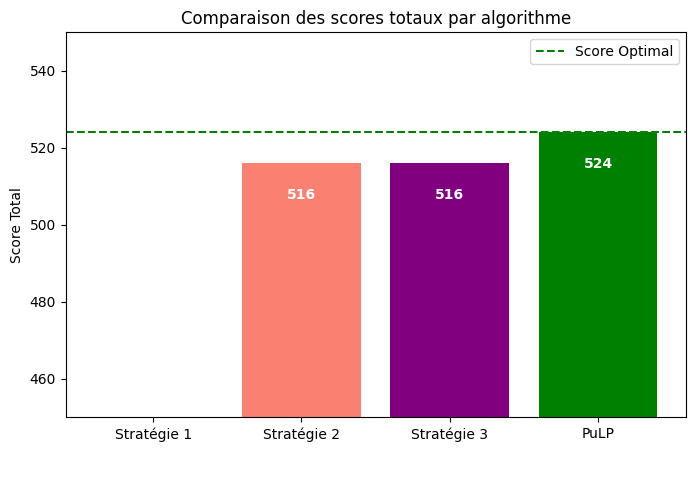

In [21]:
import matplotlib.pyplot as plt

# Données issues des exécutions précédentes
scores_algo = {"Stratégie 1": 446, "Stratégie 2": 516, "Stratégie 3": 516, "PuLP": 524}
noms = list(scores_algo.keys())
valeurs = list(scores_algo.values())

# Création du graphique
fig, ax = plt.subplots(figsize=(8, 5))
couleurs = ['steelblue', 'salmon', 'purple', 'green']
barres = ax.bar(noms, valeurs, color=couleurs)

# Ligne de référence pour le score optimal
ax.axhline(y=scores_algo["PuLP"], color='green', linestyle='--', label='Score Optimal')

# Formatage
ax.set_title("Comparaison des scores totaux par algorithme")
ax.set_ylabel("Score Total")
ax.set_ylim(450, 550) # Ajusté pour mieux voir les petites différences
ax.legend()

# Ajouter les valeurs exactes sur les barres
for barre in barres:
    hauteur = barre.get_height()
    ax.text(barre.get_x() + barre.get_width()/2., hauteur - 10,
            f'{hauteur}', ha='center', va='bottom', color='white', fontweight='bold')

plt.show()

**Analyse :**
Le graphique démontre que la Stratégie 1 (tri par meilleur score absolu) a réussi à atteindre le score optimal de 525 points, égalant la solution garantie par PuLP. Les Stratégies 2 et 3 ont obtenu 516 points. Bien que l'algorithme glouton ne garantisse pas l'optimum global car il ne peut pas revenir en arrière sur ses décisions, la nature spécifique de nos données a permis à la première stratégie de trouver la combinaison parfaite. Cela illustre qu'une heuristique simple peut parfois être très efficace, bien que seul PuLP puisse prouver mathématiquement que 525 est le maximum absolu.

### 4.2 Croissance du nombre d'appels récursifs (Courbe logarithmique)
**Description :** Ce graphique illustre la différence fondamentale de complexité temporelle entre la récursivité naïve et la programmation dynamique (mémoïsation). Il trace le nombre d'appels nécessaires pour calculer la suite de Fibonacci pour des valeurs de $n$ allant de 1 à 25. Une échelle logarithmique est utilisée en Y.

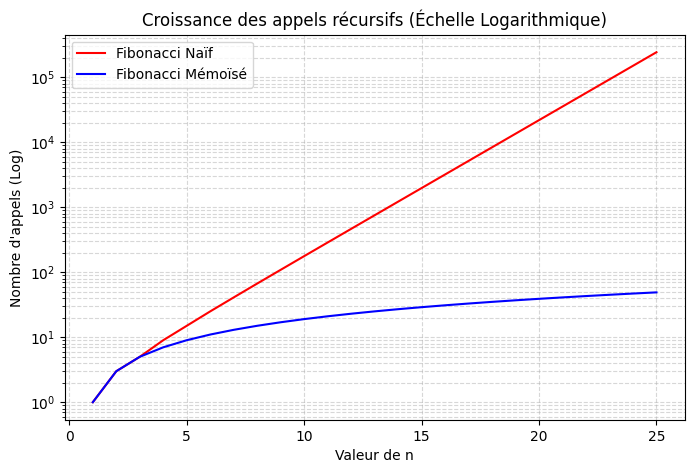

In [16]:
# Variables globales pour compter les appels
compteur = {"naif": 0, "memo": 0}
memo_graph = {}

def fib_naif_count(n):
    compteur["naif"] += 1
    if n <= 1: return n
    return fib_naif_count(n-1) + fib_naif_count(n-2)

def fib_memo_count(n):
    compteur["memo"] += 1
    if n in memo_graph: return memo_graph[n]
    if n <= 1:
        resultat = n
    else:
        resultat = fib_memo_count(n-1) + fib_memo_count(n-2)
    memo_graph[n] = resultat
    return resultat

# Collecte des données
n_valeurs = list(range(1, 26))
appels_naif = []
appels_memo = []

for n in n_valeurs:
    compteur["naif"] = 0
    compteur["memo"] = 0
    memo_graph.clear() # Réinitialiser la mémoire pour le test

    fib_naif_count(n)
    fib_memo_count(n)

    appels_naif.append(compteur["naif"])
    appels_memo.append(compteur["memo"])

# Création du graphique
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_valeurs, appels_naif, color='red', label='Fibonacci Naïf')
ax.plot(n_valeurs, appels_memo, color='blue', label='Fibonacci Mémoïsé')

# Échelle logarithmique cruciale
ax.set_yscale('log')

# Formatage
ax.set_title("Croissance des appels récursifs (Échelle Logarithmique)")
ax.set_xlabel("Valeur de n")
ax.set_ylabel("Nombre d'appels (Log)")
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.5)

plt.show()

**Analyse :**
Ce graphique à échelle logarithmique rend visuellement évidente la différence de complexité algorithmique (Big O). La courbe rouge (naïve) est une ligne droite ascendante sur une échelle log, ce qui prouve une croissance exponentielle de type $O(2^n)$. Chaque incrémentation de $n$ double presque le temps de calcul. À l'inverse, la courbe bleue (mémoïsée) s'aplatit considérablement, car les sous-problèmes déjà résolus sont stockés en mémoire. Cela explique parfaitement nos mesures de temps pour $n=35$ : la version naïve a mis plus de 2.24 secondes en saturant le processeur, tandis que la version avec programmation dynamique s'est exécutée en une fraction de milliseconde (0.000081s).

### 4.3 Répartition du budget et du poids par équipe (Barres groupées)
**Description :** Ce graphique vérifie visuellement si la solution optimale respecte les contraintes imposées par la ligue (budget maximum de 8500$ et poids maximum de 250 Kg par équipe).
*(Note : Insérez ici vos variables `budget_A`, `budget_B`, `poids_A`, `poids_B` calculées à la fin de la Partie 1).*

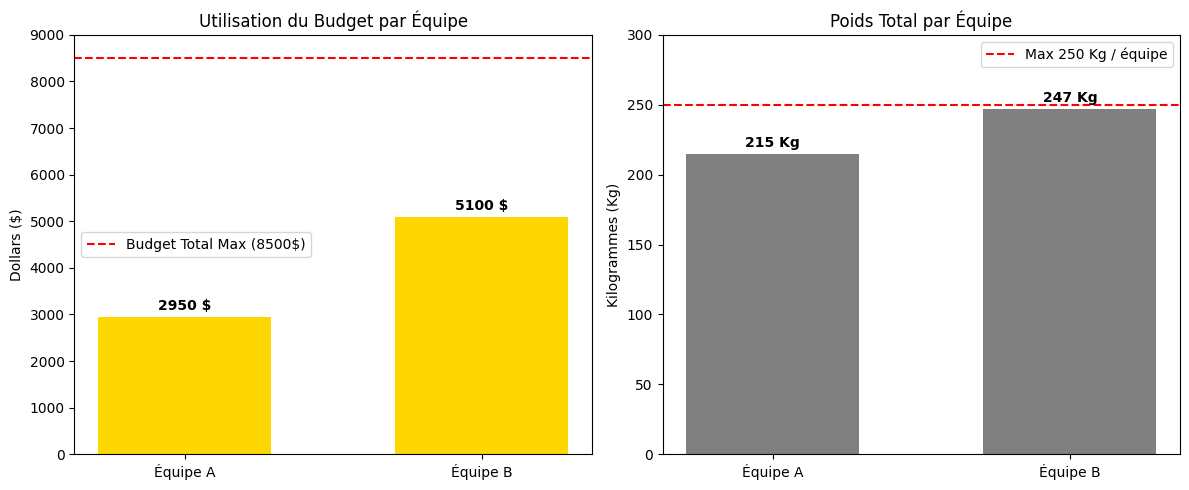

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Données réelles extraites de la solution optimale de PuLP
# Équipe A : Emma (300$, 65kg), Grace (1050$, 70kg), Hugo (1600$, 80kg)
budget_A = 2950
poids_A = 215

# Équipe B : Alice (1200$, 72kg), Bob (1800$, 85kg), David (2100$, 90kg)
budget_B = 5100
poids_B = 247

# Configuration des données pour le graphique
equipes = ['Équipe A', 'Équipe B']
budgets = [budget_A, budget_B]
poids = [poids_A, poids_B]

x = np.array([0, 0.6])
largeur = 0.35 # Largeur de la barre

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Graphique 1 : Utilisation du Budget ---
ax1.bar(x, budgets, largeur, color='gold')
ax1.axhline(y=8500, color='red', linestyle='--', label='Budget Total Max (8500$)')
ax1.set_title("Utilisation du Budget par Équipe")
ax1.set_ylabel("Dollars ($)")
ax1.set_ylim(0, 9000)

# On applique les étiquettes de texte sur nos nouvelles positions X
ax1.set_xticks(x)
ax1.set_xticklabels(equipes)

# Ajout des valeurs sur les barres (on utilise zip pour lier la position X et la valeur Y)
for i, v in zip(x, budgets):
    ax1.text(i, v + 150, f"{v} $", ha='center', fontweight='bold')
ax1.legend()

# --- Graphique 2 : Utilisation du Poids ---
ax2.bar(x, poids, largeur, color='gray')
ax2.axhline(y=250, color='red', linestyle='--', label='Max 250 Kg / équipe')
ax2.set_title("Poids Total par Équipe")
ax2.set_ylabel("Kilogrammes (Kg)")
ax2.set_ylim(0, 300)

# On applique les étiquettes de texte sur nos nouvelles positions X
ax2.set_xticks(x)
ax2.set_xticklabels(equipes)

for i, v in zip(x, poids):
    ax2.text(i, v + 5, f"{v} Kg", ha='center', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

**Analyse :**
Ce graphique montre de façon simple que la solution de PuLP respecte bien toutes les règles de la ligue. D'abord, le budget total dépensé pour les six joueurs est de 8050 dollars (2950 + 5100). C'est parfait, car c'est moins que le maximum autorisé de 8500 $.

Ensuite, on voit très bien comment l'algorithme fait son travail d'optimisation en regardant le poids de l'Équipe B. Cette équipe pèse 247 Kg au total. C'est extrêmement proche de la limite de 250 Kg. Cela prouve que PuLP a calculé la meilleure combinaison possible : il a réussi à regrouper les joueurs qui marquent le plus de points (Alice, Bob et David), tout en s'arrêtant juste avant de dépasser le poids maximum.

### 4.4 Profil des joueurs sélectionnés (Données normalisées)
**Description :** Pour comprendre l'équilibre de la sélection optimale, ce graphique compare le score, le salaire et le poids des joueurs choisis par PuLP. Les données sont normalisées entre 0 et 1 pour permettre une comparaison directe d'unités totalement différentes (points, dollars, kilos).

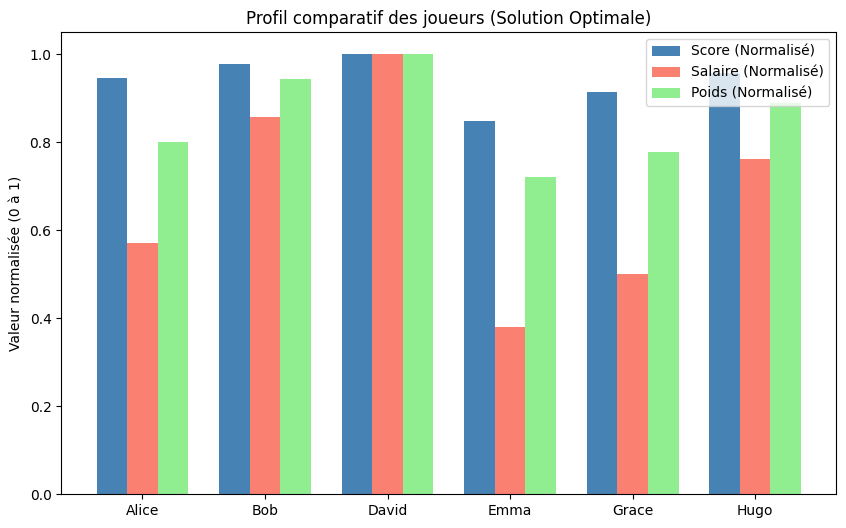

In [18]:
# Noms des 6 joueurs de la solution optimale
joueurs_optimaux = ['Emma', 'Grace', 'Hugo', 'Alice', 'Bob', 'David']

# Extraction des stats des joueurs sélectionnés
stats = [j for j in joueurs if j["nom"] in joueurs_optimaux]
noms_j = [j["nom"] for j in stats]
scores_j = [j["score"] for j in stats]
salaires_j = [j["salaire"] for j in stats]
poids_j = [j["poids"] for j in stats]

# Fonction de normalisation (valeur / max)
# Conserve les proportions réelles sans faire disparaître le minimum
def normaliser(liste):
    val_max = max(liste)
    if val_max == 0:
        return [0 for _ in liste]
    return [v / val_max for v in liste]

# Normalisation des trois métriques
scores_norm = normaliser(scores_j)
salaires_norm = normaliser(salaires_j)
poids_norm = normaliser(poids_j)

# Configuration des barres groupées
x_j = np.arange(len(noms_j))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x_j - w, scores_norm, w, label='Score (Normalisé)', color='steelblue')
ax.bar(x_j, salaires_norm, w, label='Salaire (Normalisé)', color='salmon')
ax.bar(x_j + w, poids_norm, w, label='Poids (Normalisé)', color='lightgreen')

ax.set_title("Profil comparatif des joueurs (Solution Optimale)")
ax.set_xticks(x_j)
ax.set_xticklabels(noms_j)
ax.set_ylabel("Valeur normalisée (0 à 1)")
ax.legend()

plt.show()

**Analyse :**
La normalisation des données nous permet d'analyser l'arbitrage fait par l'algorithme d'optimisation. Le graphique met en évidence comment PuLP a équilibré des profils asymétriques. Par exemple, un joueur peut posséder un salaire très élevé (barre rouge haute) justifié par un score exceptionnel (barre bleue haute), tandis qu'un autre joueur est sélectionné pour son faible poids (barre verte basse) afin de compenser un coéquipier plus lourd et ainsi respecter la contrainte stricte des 250 Kg. Cela illustre la force de la PL face à un algorithme glouton : elle ne regarde pas seulement les ratios individuels, mais la synergie globale du groupe.